In [23]:
# import libraries
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import networkx as nx 
import osmnx as ox
import folium

In [24]:
# sample points in a geospatial map
starting_pt = "PUP Sta. Mesa, Manila, Philippines"
end_pt = "UE Manila, Manila, Philippines"

start_geocode = ox.geocode(starting_pt)
end_geocode = ox.geocode(end_pt)

# converts specific points into lat and long values
print(start_geocode, end_geocode)

(14.59657, 121.0101119) (14.6012685, 120.9907855)


In [25]:
# central pt of the locations
central_pt = (
    (start_geocode[0] + end_geocode[0]) / 2,
    (start_geocode[1] + end_geocode[1]) / 2
)

central_pt

(14.59891925, 121.00044869999999)

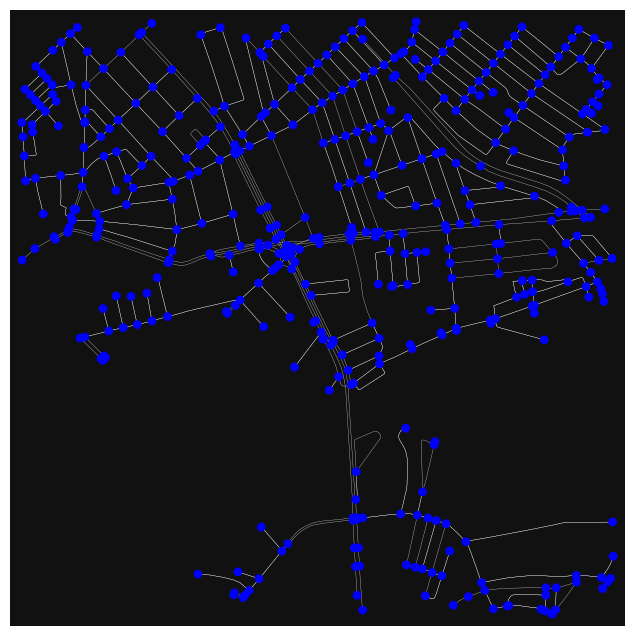

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [26]:
# raw plotting of the geospatial graph

graph = ox.graph_from_point(central_pt, dist=1000, network_type='drive')
ox.plot_graph(
    graph,
    edge_color='white',
    node_color='blue',
    node_size=40,
    edge_linewidth=0.2
              )

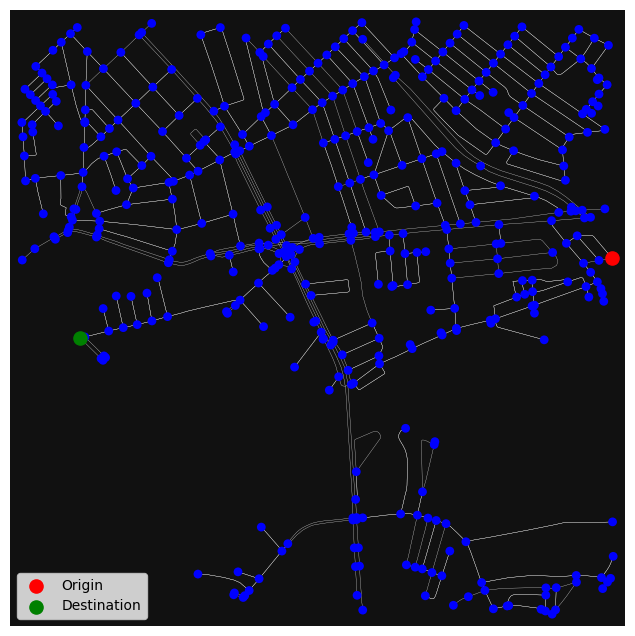

In [27]:
# obtaining both x and y values for each origin and destination's lat and long
origin = ox.distance.nearest_nodes(graph, start_geocode[1], end_geocode[0])
destination = ox.distance.nearest_nodes(graph, end_geocode[1], start_geocode[0])


# plotting of the geospatial graph
fig, ax = ox.plot_graph(
    graph,
    edge_color='white',
    node_color='blue',
    node_size=40,
    edge_linewidth=0.2, 
    show=False, close=False
)

origin_xy = (graph.nodes[origin]['x'], graph.nodes[origin]['y'])
destination_xy = (graph.nodes[destination]['x'], graph.nodes[destination]['y'])

ax.scatter(*origin_xy, s=90, color='red', label='Origin', zorder=3)
ax.scatter(*destination_xy, s=90, color='green', label='Destination', zorder=3)
ax.legend()
plt.show()

In [28]:
# sample routing using dijkstra

routing = nx.shortest_path(graph, origin, destination, weight='length', method='dijkstra') # provides all of the nodes through lat and long
routing_length = nx.shortest_path_length(graph, origin, destination, weight='length', method='dijkstra') # length of meters from point x and point y

routing_length

np.float64(2223.656333463331)

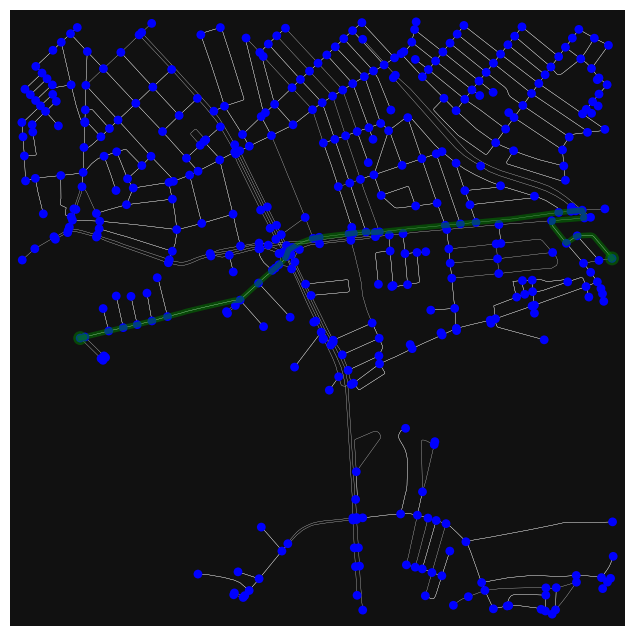

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [29]:
ox.plot_graph_route(
    graph, routing,
    edge_color='white',
    node_color='blue',
    node_size=40,
    edge_linewidth=0.2,
    route_color='green'
)

In [30]:
# using folium map
m = folium.Map(
    location=central_pt,
    zoom_start=15,
    tiles="Cartodb dark_matter",
    zoom_control=False,
    dragging=False,
    scrollWheelZoom=False
)

In [31]:
edges_gdf = ox.graph_to_gdfs(graph, nodes=False, edges=True)

for _, row in edges_gdf.iterrows():
    coords = [(lat, lon) for lon, lat in row['geometry'].coords]
    folium.PolyLine(coords, color='#800000', weight=1, opacity=0.7).add_to(m)

route_coords = [
    (graph.nodes[node]['y'], graph.nodes[node]['x']) for node in routing
]

route_coords

[(14.6007095, 121.0096661),
 (14.601394, 121.0085753),
 (14.6011668, 121.0082373),
 (14.6018515, 121.0077729),
 (14.6019345, 121.0088023),
 (14.6021693, 121.0087331),
 (14.6021506, 121.008529),
 (14.6021378, 121.0083807),
 (14.6021019, 121.0079984),
 (14.6018004, 121.0054086),
 (14.6017555, 121.0049208),
 (14.6017118, 121.0044483),
 (14.6015121, 121.0023871),
 (14.6014983, 121.0022544),
 (14.6015089, 121.0019687),
 (14.6014727, 121.0015738),
 (14.6014551, 121.0014359),
 (14.601349, 121.0005044),
 (14.6013161, 121.0003164),
 (14.6010407, 120.9996659),
 (14.6009722, 120.9995468),
 (14.6007628, 120.9994701),
 (14.6005188, 120.9992417),
 (14.6004156, 120.9991262),
 (14.6003467, 120.999038),
 (14.5999629, 120.998605),
 (14.5994466, 120.998029),
 (14.5989467, 120.9957588),
 (14.5988159, 120.9952703),
 (14.5987041, 120.9948105),
 (14.5986129, 120.9943735),
 (14.5985112, 120.9939187),
 (14.5983287, 120.9931743),
 (14.5982971, 120.9930263)]

In [32]:
folium.PolyLine(route_coords, color = 'green').add_to(m)

start_node_data = graph.nodes[origin]
end_node_data = graph.nodes[destination]

# adding start and end pts
folium.Marker(
    location=[start_node_data['y'], start_node_data['x']], 
    popup="Start Point",
    icon=folium.Icon(angle=180, color='green')
).add_to(m)

folium.Marker(
    location=[end_node_data['y'], end_node_data['x']], 
    popup="End Point",
    icon=folium.Icon(angle=180, color='red')
).add_to(m)

In [33]:
m